# ARTI308 / Data Visualization Lab – Solution (BMW Dataset)
This notebook performs **Exploratory Data Analysis (EDA)** and **visualizations** on `bmw.csv`.

**Dataset columns:** model, year, price, transmission, mileage, fuelType, tax, mpg, engineSize.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme()  

df = pd.read_csv("bmw.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


## 1) Basic checks

In [22]:
print("Shape:", df.shape)

df.info()

Shape: (10781, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [23]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [24]:
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)



Duplicate rows: 117


## 2) Summary statistics

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,10781.0,2017.078935,2.349038,1996.0,2016.0,2017.0,2019.0,2020.0
price,10781.0,22733.408867,11415.528189,1200.0,14950.0,20462.0,27940.0,123456.0
mileage,10781.0,25496.986550,25143.192559,1.0,5529.0,18347.0,38206.0,214000.0
tax,10781.0,131.702068,61.510755,0.0,135.0,145.0,145.0,580.0
mpg,10781.0,56.399035,31.336958,5.5,45.6,53.3,62.8,470.8
engineSize,10781.0,2.167767,0.552054,0.0,2.0,2.0,2.0,6.6


In [26]:
df.describe(include=['object']).T

,count,unique,top,freq
model,10781,24,3 Series,2443
transmission,10781,3,Semi-Auto,4666
fuelType,10781,5,Diesel,7027


## 3) Univariate analysis (one variable at a time)

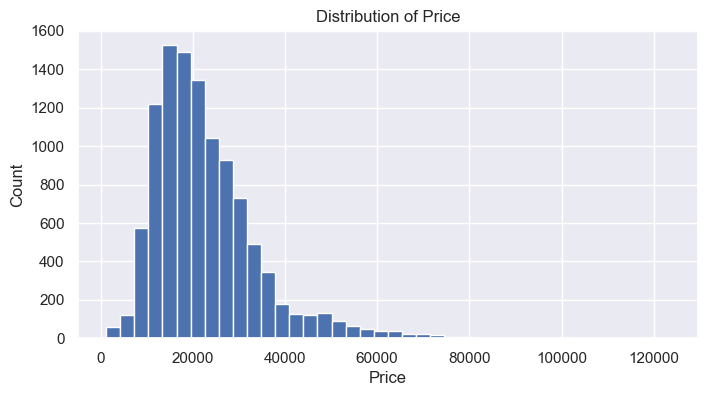

In [27]:
plt.figure(figsize=(8,4))
plt.hist(df['price'], bins=40)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

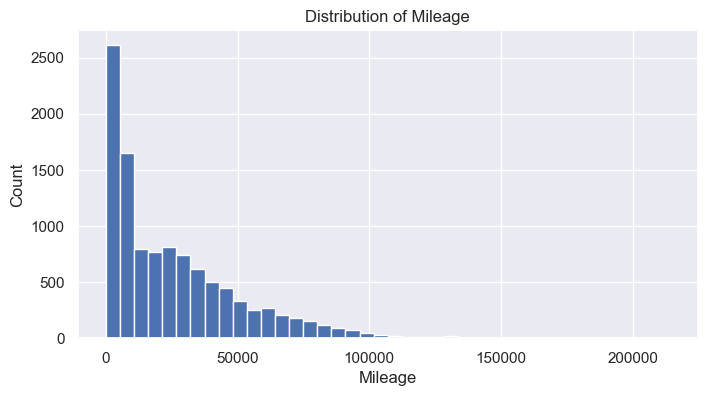

In [28]:
plt.figure(figsize=(8,4))
plt.hist(df['mileage'], bins=40)
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Count")
plt.show()

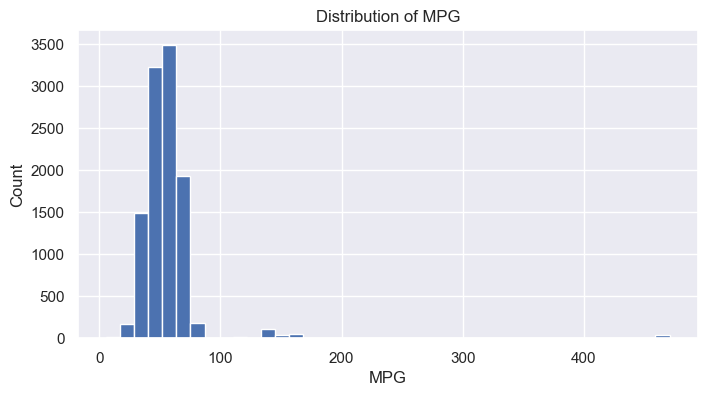

In [29]:
plt.figure(figsize=(8,4))
plt.hist(df['mpg'], bins=40)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Count")
plt.show()

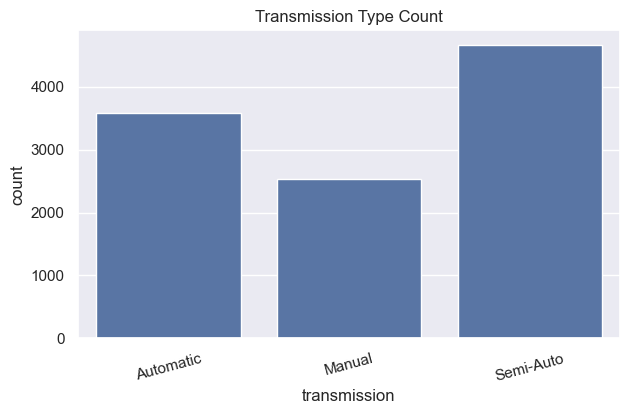

In [30]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='transmission')
plt.title("Transmission Type Count")
plt.xticks(rotation=15)
plt.show()

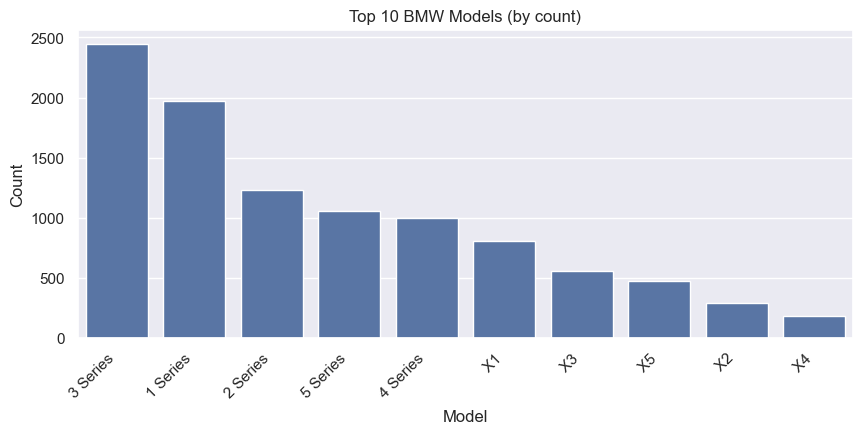

In [31]:
top_models = df['model'].value_counts().head(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top_models.index, y=top_models.values)
plt.title("Top 10 BMW Models (by count)")
plt.xlabel("Model")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

## 4) Bivariate analysis (relationships)

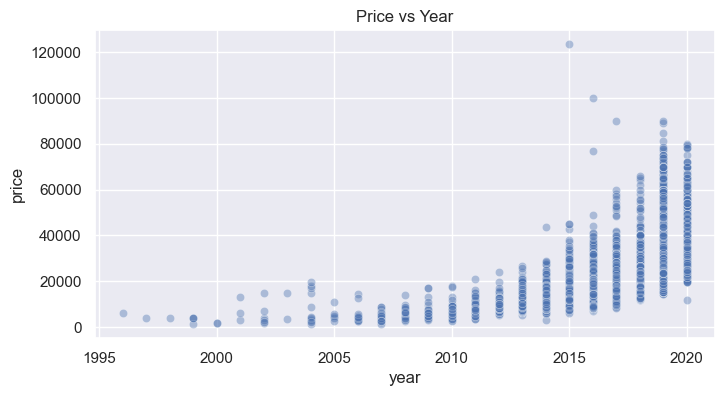

In [32]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='year', y='price', alpha=0.4)
plt.title("Price vs Year")
plt.show()

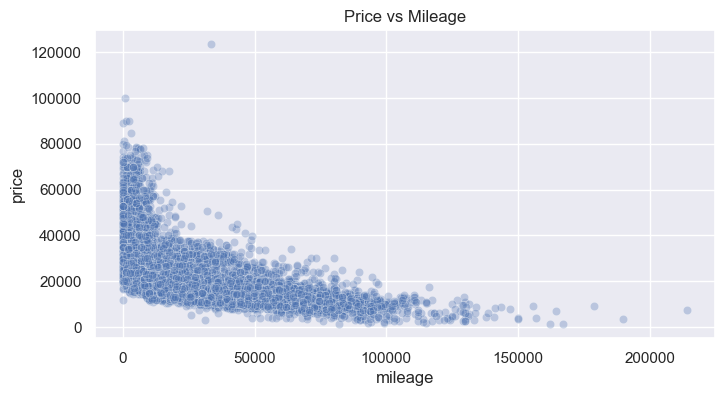

In [33]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.3)
plt.title("Price vs Mileage")
plt.show()

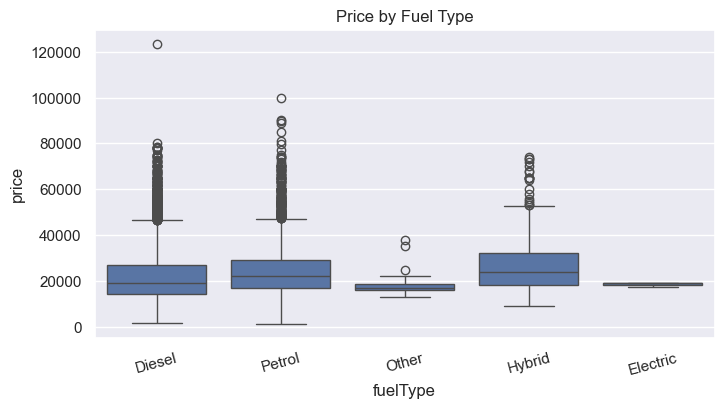

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='fuelType', y='price')
plt.title("Price by Fuel Type")
plt.xticks(rotation=15)
plt.show()

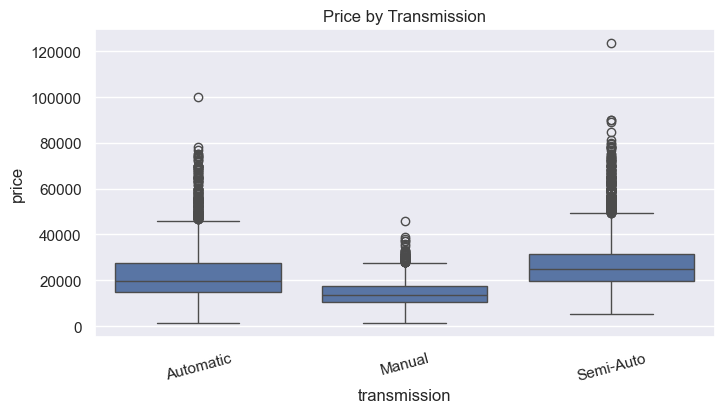

In [35]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='transmission', y='price')
plt.title("Price by Transmission")
plt.xticks(rotation=15)
plt.show()

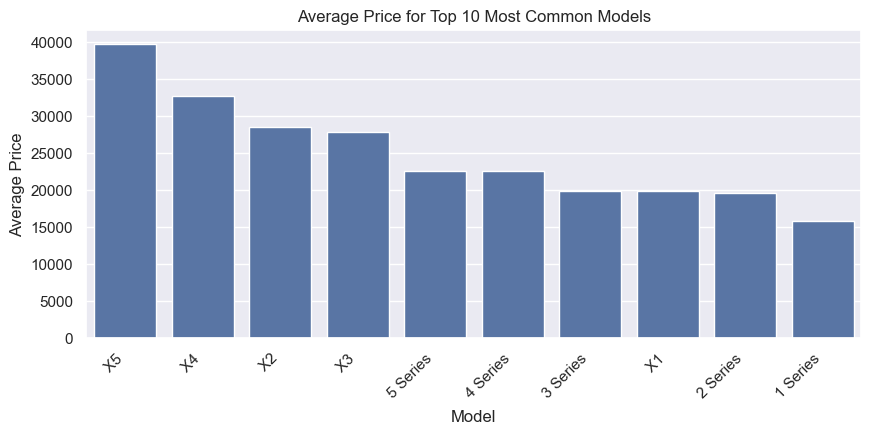

In [36]:
common_models = df['model'].value_counts().head(10).index
avg_price_by_model = (df[df['model'].isin(common_models)]
                      .groupby('model')['price']
                      .mean()
                      .sort_values(ascending=False))

plt.figure(figsize=(10,4))
sns.barplot(x=avg_price_by_model.index, y=avg_price_by_model.values)
plt.title("Average Price for Top 10 Most Common Models")
plt.xlabel("Model")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha='right')
plt.show()

## 5) Correlation matrix (numeric columns)

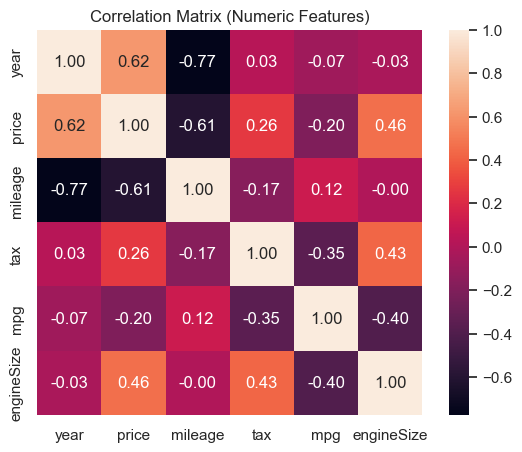

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.623756,-0.774382,0.025200,-0.071762,-0.026337
price,0.623756,1.000000,-0.605397,0.263484,-0.204882,0.460196
mileage,-0.774382,-0.605397,1.000000,-0.170747,0.118609,-0.002540
tax,0.025200,0.263484,-0.170747,1.000000,-0.351798,0.429616
mpg,-0.071762,-0.204882,0.118609,-0.351798,1.000000,-0.399844
engineSize,-0.026337,0.460196,-0.002540,0.429616,-0.399844,1.000000


In [37]:
num_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

corr

## 6) Simple time-based / trend-style analysis

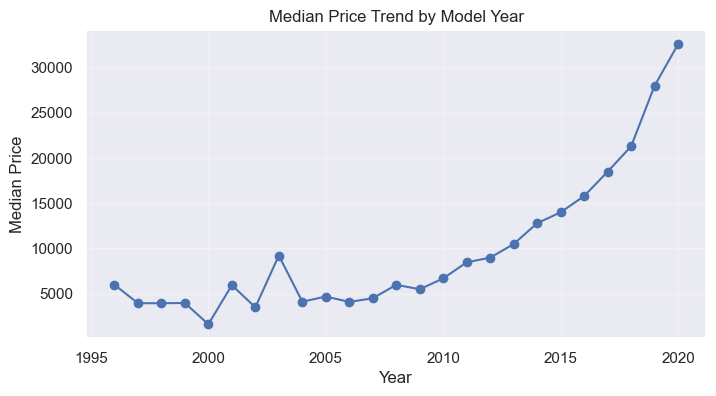

In [38]:
trend = df.groupby('year')['price'].median().sort_index()

plt.figure(figsize=(8,4))
plt.plot(trend.index, trend.values, marker='o')
plt.title("Median Price Trend by Model Year")
plt.xlabel("Year")
plt.ylabel("Median Price")
plt.grid(True, alpha=0.3)
plt.show()

## 7) Extra: Quick insights (optional)

In [39]:
df['fuelType'].value_counts()

fuelType
Diesel      7027
Petrol      3417
Hybrid       298
Other         36
Electric       3
Name: count, dtype: int64

In [40]:
model_stats = (df.groupby('model')
               .agg(count=('price','size'),
                    median_price=('price','median'))
               .query("count >= 50")
               .sort_values('median_price', ascending=False))
model_stats.head(10)

,count,median_price
model,,
X7,55,69146.0
X5,468,44151.0
M4,125,43480.0
X6,106,40207.0
7 Series,106,37224.5
X4,179,34995.0
Z4,108,30995.0
X3,551,29357.0
X2,288,27989.5
